# Heart Disease Dataset - Comprehensive Exercises

## Course: MAT0611 - Mathematics for Machine Learning

## Setup and Data Loading

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

# Set random seed for reproducibility
np.random.seed(42)

# Style settings
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

In [14]:
# Load Heart Disease UCI Dataset
# Dataset source: https://archive.ics.uci.edu/ml/datasets/heart+disease

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

column_names = [
    "age",  # Age in years
    "sex",  # Sex (1 = male; 0 = female)
    "cp",  # Chest pain type (1-4)
    "trestbps",  # Resting blood pressure (mm Hg)
    "chol",  # Serum cholesterol in mg/dl
    "fbs",  # Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
    "restecg",  # Resting electrocardiographic results (0-2)
    "thalach",  # Maximum heart rate achieved
    "exang",  # Exercise induced angina (1 = yes; 0 = no)
    "oldpeak",  # ST depression induced by exercise relative to rest
    "slope",  # Slope of the peak exercise ST segment (1-3)
    "ca",  # Number of major vessels (0-3) colored by fluoroscopy
    "thal",  # Thalassemia (3 = normal; 6 = fixed defect; 7 = reversible defect)
    "target",  # Diagnosis of heart disease (0 = no disease, 1-4 = disease)
]

df = pd.read_csv(url, names=column_names, na_values="?")

# Convert target to binary (0 = no disease, 1 = disease)
df["target"] = (df["target"] > 0).astype(int)

# Remove rows with missing values for cleaner exercises
df = df.dropna()

print(f"Dataset shape: {df.shape}")
print(f"\nNumber of patients: {len(df)}")
print(f"Number of variables: {len(df.columns)}")
print(f"\nTarget distribution:")
print(df["target"].value_counts())

df.head(10)

Dataset shape: (297, 14)

Number of patients: 297
Number of variables: 14

Target distribution:
target
0    160
1    137
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [15]:
# Basic descriptive statistics
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00
mean,54.54,0.68,3.16,131.69,247.35,0.14,1.00,149.60,0.33,1.06,1.60,0.68,4.73,0.46
std,9.05,0.47,0.96,17.76,52.00,0.35,0.99,22.94,0.47,1.17,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.00,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,243.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,276.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


---
# Part 1: Distribution Fitting and MLE Parameter Estimation

## Exercise 1.1: Normal Distribution - Cholesterol Levels

**Context:** Cholesterol levels in populations often follow a normal distribution.

**Task:** Using Maximum Likelihood Estimation, estimate the parameters $\mu$ and $\sigma^2$ for cholesterol levels.

Small sample of cholesterol levels (n=20):
[167. 177. 197. 197. 214. 223. 230. 235. 239. 240. 249. 254. 264. 265.
 265. 267. 288. 294. 294. 308.]

Sum: 4867.00
Sum of squares: 1213839.00


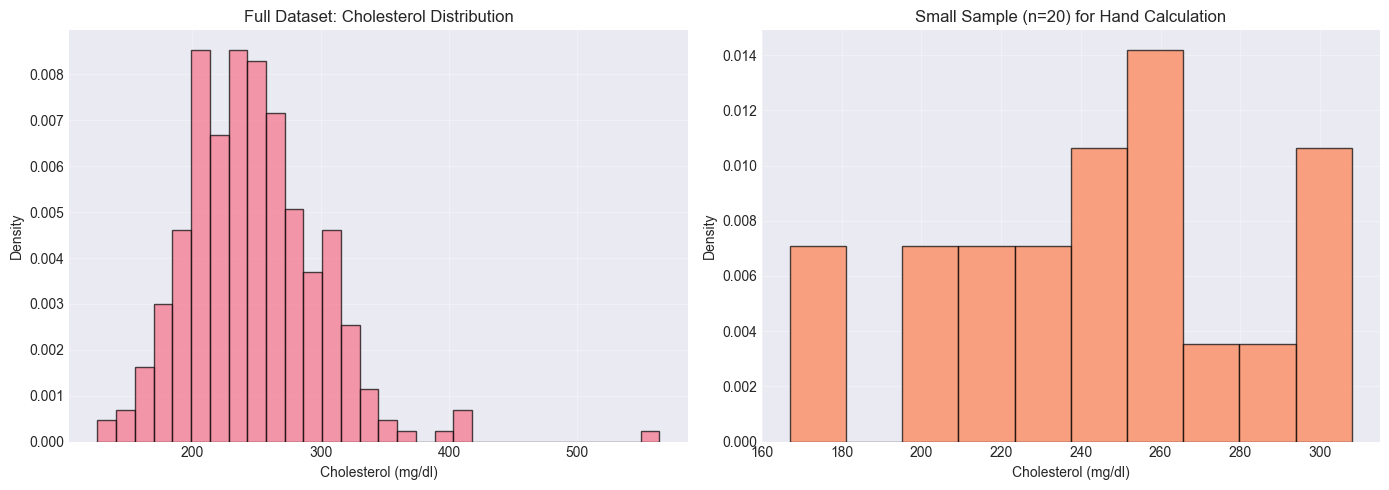

In [16]:
# For hand calculation, we'll use a small sample
np.random.seed(123)
small_sample_chol = df["chol"].sample(n=20, random_state=123).sort_values().values

print("Small sample of cholesterol levels (n=20):")
print(small_sample_chol)
print(f"\nSum: {small_sample_chol.sum():.2f}")
print(f"Sum of squares: {(small_sample_chol**2).sum():.2f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(df["chol"], bins=30, density=True, alpha=0.7, edgecolor="black")
axes[0].set_xlabel("Cholesterol (mg/dl)")
axes[0].set_ylabel("Density")
axes[0].set_title("Full Dataset: Cholesterol Distribution")
axes[0].grid(True, alpha=0.3)

# Small sample
axes[1].hist(
    small_sample_chol,
    bins=10,
    density=True,
    alpha=0.7,
    edgecolor="black",
    color="coral",
)
axes[1].set_xlabel("Cholesterol (mg/dl)")
axes[1].set_ylabel("Density")
axes[1].set_title("Small Sample (n=20) for Hand Calculation")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Given information:**

For a single observation $x$ from $N(\mu, \sigma^2)$, the probability density function (PDF) is:

$$f(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**Questions to answer:**

1. Given $n$ i.i.d. observations $x_1, x_2, \ldots, x_n$ from $N(\mu, \sigma^2)$:
   - Write the likelihood function $L(\mu, \sigma^2)$ as the product of individual PDFs
   - Derive the log-likelihood function $\ell(\mu, \sigma^2) = \log L(\mu, \sigma^2)$
   - Simplify your expression

2. By taking derivatives of the log-likelihood with respect to $\mu$ and $\sigma^2$ and setting them to zero, derive the MLE estimators $\hat{\mu}_{MLE}$ and $\hat{\sigma}^2_{MLE}$

3. Calculate $\hat{\mu}_{MLE}$ and $\hat{\sigma}^2_{MLE}$ from the sample above


4. Is $\hat{\sigma}^2_{MLE}$ a biased estimator? Show that $E[\hat{\sigma}^2_{MLE}] = \frac{n-1}{n}\sigma^2


5. What is the unbiased estimator for $\sigma^2$? How does it differ from the MLE?

6.  Why might we prefer the MLE even though it's biased? When does the bias become negligible?

## Exercise 1.2: Exponential Distribution - ST Depression

**Context:** The variable `oldpeak` (ST depression) is always non-negative and might follow an exponential distribution.

**Task:** Test if ST depression follows an exponential distribution and estimate the rate parameter $\lambda$.

Small sample of ST depression values (n=15):
[0.2 0.5 0.6 1.  1.4 1.5 1.6 1.8 2.  2.2 2.3 2.8 3.  3.5 3.8]

Sum: 28.200
Sample mean: 1.880


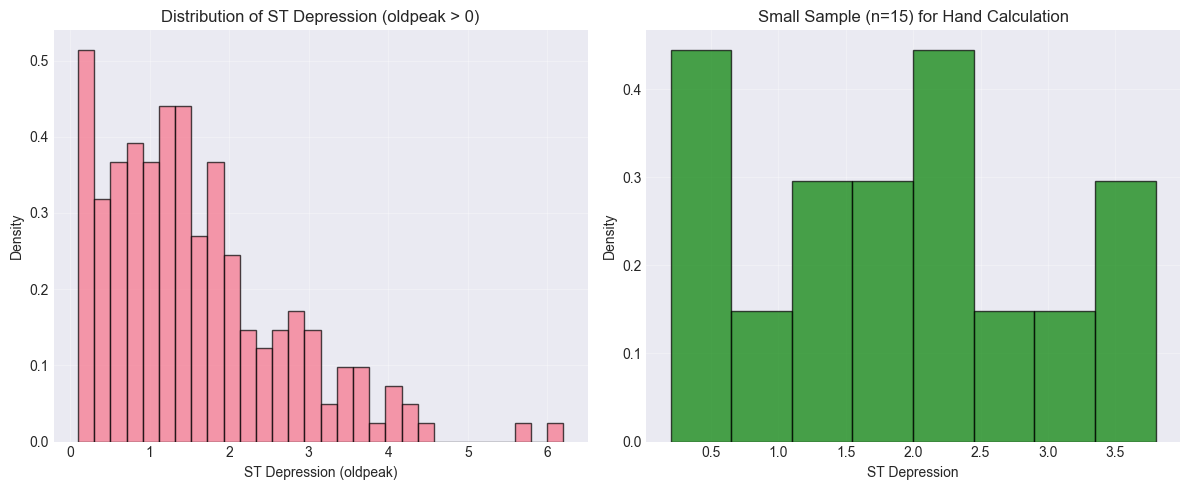

In [17]:
# Use patients with positive oldpeak values
oldpeak_positive = df[df["oldpeak"] > 0]["oldpeak"].values

# Small sample for hand calculation
np.random.seed(456)
small_sample_oldpeak = np.random.choice(oldpeak_positive, size=15, replace=False)
small_sample_oldpeak = np.sort(small_sample_oldpeak)

print("Small sample of ST depression values (n=15):")
print(small_sample_oldpeak.round(2))
print(f"\nSum: {small_sample_oldpeak.sum():.3f}")
print(f"Sample mean: {small_sample_oldpeak.mean():.3f}")

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(oldpeak_positive, bins=30, density=True, alpha=0.7, edgecolor="black")
plt.xlabel("ST Depression (oldpeak)")
plt.ylabel("Density")
plt.title("Distribution of ST Depression (oldpeak > 0)")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(
    small_sample_oldpeak,
    bins=8,
    density=True,
    alpha=0.7,
    edgecolor="black",
    color="green",
)
plt.xlabel("ST Depression")
plt.ylabel("Density")
plt.title("Small Sample (n=15) for Hand Calculation")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Given information:**

For the exponential distribution with parameter $\lambda$, the PDF is:

$$f(x;\lambda) = \lambda e^{-\lambda x} \quad \text{for } x \geq 0$$

**Questions to answer:**

1. Given $n$ i.i.d. observations $x_1, x_2, \ldots, x_n$ from the exponential distribution:
   - Write the likelihood function $L(\lambda)$ as the product of individual PDFs
   - Derive the log-likelihood function $\ell(\lambda) = \log L(\lambda)$
   - Simplify your expression

2. By taking the derivative of the log-likelihood with respect to $\lambda$ and setting it to zero, derive the MLE estimator $\hat{\lambda}_{MLE}$

3. Calculate $\hat{\lambda}_{MLE}$ from the sample above


4. What is the relationship between $\lambda$ and the mean of the exponential distribution? Verify this with your sample.

5. Suppose you have waiting times between events that follow an exponential distribution. You observe 5 waiting times: 0.5, 1.2, 0.8, 2.1, 0.9 minutes. Estimate $\lambda$ and interpret what it means in this context. What is the expected waiting time?


## Exercise 1.3: Bayesian Inference - Beta Prior for Disease Probability

**Context:** Instead of using MLE, we can take a Bayesian approach to estimate the probability of heart disease $p = P(\text{disease})$.

**Task:** Use a Beta prior distribution and calculate the posterior distribution after observing data.

In [18]:
# Small sample of disease outcomes (binary: 0 or 1)
np.random.seed(999)
disease_sample = df["target"].sample(n=20, random_state=999).values

n_total = len(disease_sample)
n_disease = disease_sample.sum()
n_no_disease = n_total - n_disease

print("Sample of heart disease outcomes (n=20):")
print(disease_sample)
print(f"\nNumber with disease: {n_disease}")
print(f"Number without disease: {n_no_disease}")
print(f"Sample proportion: {n_disease}/{n_total} = {n_disease/n_total:.3f}")

Sample of heart disease outcomes (n=20):
[1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 0 1 0 0 1]

Number with disease: 13
Number without disease: 7
Sample proportion: 13/20 = 0.650


**Given information:**

The **Beta distribution** is defined as:
$$\text{Beta}(p; \alpha, \beta) = \frac{p^{\alpha-1}(1-p)^{\beta-1}}{B(\alpha,\beta)} \quad \text{for } 0 \leq p \leq 1$$

where $B(\alpha, \beta) = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$ is the Beta function (normalizing constant).

**Key properties:**
- Mean: $E[p] = \frac{\alpha}{\alpha+\beta}$
- Mode (for $\alpha, \beta > 1$): $\text{Mode}[p] = \frac{\alpha-1}{\alpha+\beta-2}$
- Variance: $\text{Var}[p] = \frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$

**Conjugate prior property:** If we have:
- Prior: $p \sim \text{Beta}(\alpha, \beta)$
- Likelihood: $k$ successes in $n$ trials (Binomial)

Then the posterior is:
$$p \mid \text{data} \sim \text{Beta}(\alpha + k, \beta + (n-k))$$

**Questions to answer:**

1. **Prior specification:**
   - Suppose we use a prior $\text{Beta}(2, 2)$. What is the prior mean? What does this prior express about our initial belief?
   - How would a $\text{Beta}(1, 1)$ prior differ? What about $\text{Beta}(10, 10)$?

2. **Posterior calculation:**
   - Given the sample above with $k = $ {number with disease} successes out of $n = 20$ trials
   - Calculate the posterior distribution parameters: $\alpha_{\text{post}}$ and $\beta_{\text{post}}$
   - What is the posterior mean? How does it compare to the sample proportion?

3. **Posterior credible interval:**
   - A 95% credible interval can be computed using the quantiles of the posterior Beta distribution
   - For Beta$(\alpha, \beta)$, the 95% CI is $[\text{Beta}^{-1}(0.025; \alpha, \beta), \text{Beta}^{-1}(0.975; \alpha, \beta)]$
   - Interpret what a credible interval means (contrast with confidence interval)

4. **Comparing with MLE:**
   - The MLE estimate for $p$ is simply $\hat{p}_{MLE} = k/n$
   - How does the posterior mean relate to the MLE and prior mean?
   - Write the posterior mean as a weighted average

5. **Effect of sample size:**
   - If we observed 100 patients instead of 20 (with the same proportion), how would the posterior change?
   - What happens to the influence of the prior as $n \to \infty$?

6. Suppose you observe 3 successes out of 5 trials with a $\text{Beta}(2, 3)$ prior. Calculate the posterior mean and compare it to the MLE. Which is closer to 0.6: the prior mean, MLE, or posterior mean? Why?

7.  Why is the Beta distribution a natural choice for a prior on a probability? What makes it "conjugate" to the Binomial likelihood?

---
# Part 2: Hypothesis Testing

## Exercise 2.1: One-Sample t-test - Average Age

**Context:** A cardiologist claims that the average age of patients with heart conditions is 55 years.

**Task:** Test this claim using a one-sample t-test at $\alpha = 0.05$.

**Questions to answer:**

1. State the null and alternative hypotheses (two-sided test)

2. List the assumptions required for a one-sample t-test. Which of these assumptions is most critical?

3. Calculate the test statistic: $t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}}$

4. Determine the degrees of freedom and find the critical value for $\alpha = 0.05$ (two-sided)

   - *Critical value for t₂₄, α/2 = 0.025: ±2.064*8.  What is the difference between statistical significance and practical significance? Could our result be statistically significant but not practically important?



5. Make a decision: Reject or fail to reject $H_0$? Interpret the result in context.7. Explain what the p-value represents in this specific context. If p-value = 0.03, what would you conclude?


6. If we had used a one-sided test instead (testing if average age is greater than 55), how would the critical value and conclusion change? 

## Exercise 2.2: Two-Sample t-test - Cholesterol by Sex

**Context:** Do males and females have different average cholesterol levels?

**Task:** Perform an independent two-sample t-test (use Welch's t-test which doesn't assume equal variances).

**Questions to answer:**

1. State the null and alternative hypotheses

2. Why use Welch's t-test instead of the standard two-sample t-test? What assumption does Welch's test relax?

3. Calculate the test statistic using Welch's formula:
   $$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

4. Calculate the degrees of freedom using the Welch-Satterthwaite equation:
   $$df = \frac{\left(\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}\right)^2}{\frac{(s_1^2/n_1)^2}{n_1-1} + \frac{(s_2^2/n_2)^2}{n_2-1}}$$

7. If you had to choose between a two-sample t-test and a Mann-Whitney U test for this data, which would you choose and why?

5. With df ≈ 22 and α = 0.05 (two-sided), critical value ≈ ±2.074. Make a decision.

6. Before running the test, how would you check if the equal variance assumption is reasonable? What would you look for?

Group 1 (Males): n₁=15, x̄₁=227.00, s₁=51.22, s₁²=2623.00

Group 2 (Females): n₂=12, x̄₂=271.58, s₂=61.64, s₂²=3798.99

## Exercise 2.3: Chi-Square Test - Sex vs. Heart Disease

**Context:** Is there an association between sex and the presence of heart disease?

**Task:** Perform a chi-square test of independence.

Observed Frequencies (Contingency Table):
            No Disease (0)  Disease (1)
Female (0)              71           25
Male (1)                89          112

Row totals: [ 96 201]
Column totals: [160 137]
Grand total: 297


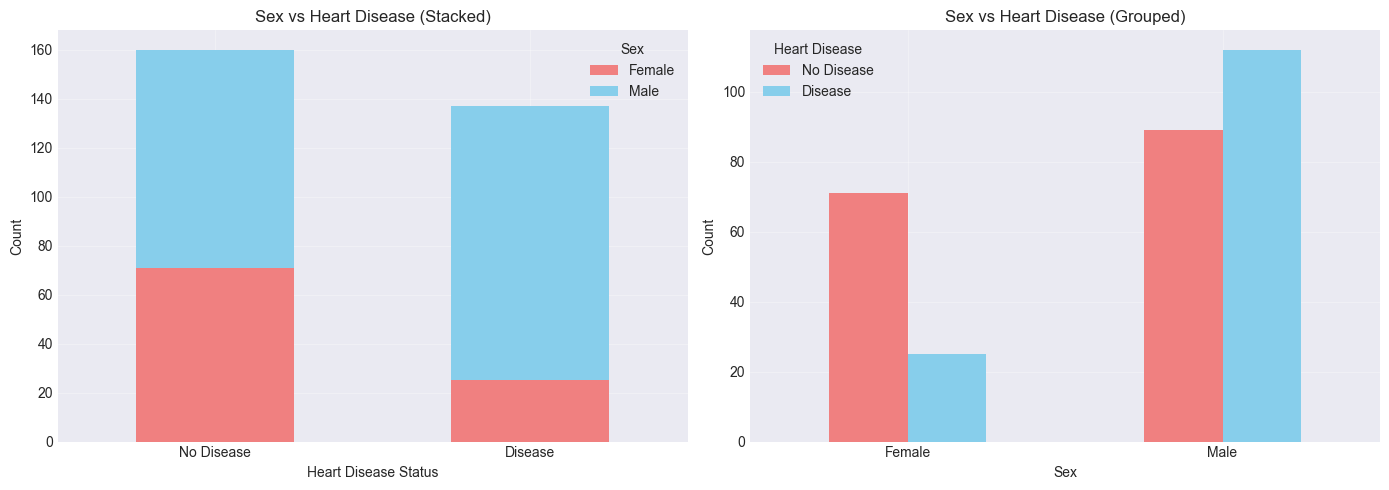

In [19]:
# Create contingency table
contingency_table = pd.crosstab(
    df["sex"], df["target"], rownames=["Sex"], colnames=["Heart Disease"]
)
contingency_table.index = ["Female (0)", "Male (1)"]
contingency_table.columns = ["No Disease (0)", "Disease (1)"]

print("Observed Frequencies (Contingency Table):")
print(contingency_table)
print(f"\nRow totals: {contingency_table.sum(axis=1).values}")
print(f"Column totals: {contingency_table.sum(axis=0).values}")
print(f"Grand total: {contingency_table.sum().sum()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
contingency_table.T.plot(
    kind="bar", stacked=True, ax=axes[0], color=["lightcoral", "skyblue"]
)
axes[0].set_xlabel("Heart Disease Status")
axes[0].set_ylabel("Count")
axes[0].set_title("Sex vs Heart Disease (Stacked)")
axes[0].legend(title="Sex", labels=["Female", "Male"])
axes[0].set_xticklabels(["No Disease", "Disease"], rotation=0)
axes[0].grid(True, alpha=0.3)

# Grouped bar chart
contingency_table.plot(kind="bar", ax=axes[1], color=["lightcoral", "skyblue"])
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Count")
axes[1].set_title("Sex vs Heart Disease (Grouped)")
axes[1].legend(title="Heart Disease", labels=["No Disease", "Disease"])
axes[1].set_xticklabels(["Female", "Male"], rotation=0)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Questions to answer:**

1. State the null and alternative hypotheses for a chi-square test of independence

2. Calculate the expected frequencies for each cell using:
   $$E_{ij} = \frac{(\text{row } i \text{ total}) \times (\text{column } j \text{ total})}{\text{grand total}}$$

3. Calculate the chi-square test statistic:
   $$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$


4. Determine degrees of freedom: $df = (r-1)(c-1)$ where $r$ = rows, $c$ = columns



5. Critical value for $\chi^2_1$ at $\alpha = 0.05$: 3.841. Make a decision and interpret.


6. What condition must the expected frequencies satisfy for the chi-square test to be valid? Why?

7. Suppose you wanted to test if chest pain type (4 categories) is associated with heart disease (binary). What would be the degrees of freedom for this chi-square test?

8.  How is the chi-square test of independence different from a chi-square goodness-of-fit test?

---
# Part 3: Linear Regression

## Exercise 3.1: Simple Linear Regression - Age vs. Blood Pressure

**Context:** Does resting blood pressure increase with age?

**Task:** Analyze the fitted regression model: $\text{BP} = \beta_0 + \beta_1 \cdot \text{Age} + \epsilon$

Sample data for regression (n=30)
Age range: 35.0 to 70.0 years
BP range: 94.0 to 178.0 mm Hg


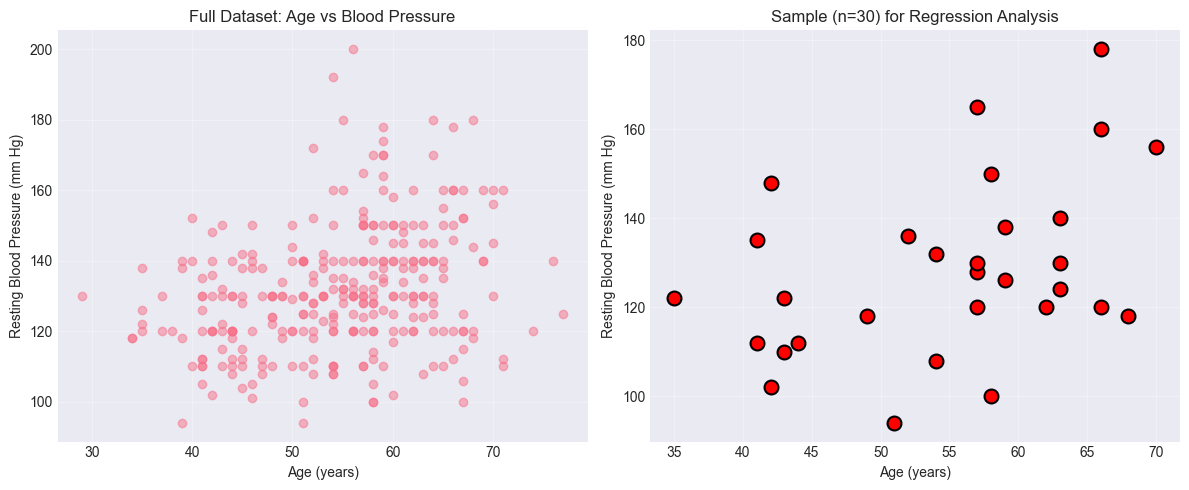

In [20]:
# Sample for regression analysis
np.random.seed(555)
sample_indices = np.random.choice(len(df), size=30, replace=False)
age_reg = df.iloc[sample_indices]["age"].values
bp_reg = df.iloc[sample_indices]["trestbps"].values

print("Sample data for regression (n=30)")
print(f"Age range: {age_reg.min()} to {age_reg.max()} years")
print(f"BP range: {bp_reg.min()} to {bp_reg.max()} mm Hg")

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df["age"], df["trestbps"], alpha=0.5)
plt.xlabel("Age (years)")
plt.ylabel("Resting Blood Pressure (mm Hg)")
plt.title("Full Dataset: Age vs Blood Pressure")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(age_reg, bp_reg, s=100, color="red", edgecolor="black", linewidth=1.5)
plt.xlabel("Age (years)")
plt.ylabel("Resting Blood Pressure (mm Hg)")
plt.title("Sample (n=30) for Regression Analysis")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Fit linear regression using statsmodels
import statsmodels.api as sm

# Add constant for intercept
X_with_const = sm.add_constant(age_reg)

# Fit OLS model
model = sm.OLS(bp_reg, X_with_const).fit()

# Display model summary
print("Linear Regression Model Summary:")
print("=" * 80)
print(model.summary())

Linear Regression Model Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     5.295
Date:                Wed, 11 Feb 2026   Prob (F-statistic):             0.0290
Time:                        14:33:23   Log-Likelihood:                -128.90
No. Observations:                  30   AIC:                             261.8
Df Residuals:                      28   BIC:                             264.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         83.61

**Questions to answer based on the model summary:**

1. **Coefficient interpretation:**
   - What is the estimated value of $\hat{\beta}_1$ (slope)?
   - Interpret this value: What does it mean in the context of blood pressure and age?
   - What is the estimated value of $\hat{\beta}_0$ (intercept)? Does it have a meaningful interpretation?

2. **Hypothesis testing:**
   - What are the null and alternative hypotheses being tested for the age coefficient?
   - What is the t-statistic for the age coefficient? How is it calculated?
   - What is the p-value? What does it tell us?
   - At $\alpha = 0.05$, is the relationship between age and blood pressure statistically significant?

3. **Confidence intervals:**
   - Report the 95% confidence interval for $\beta_1$
   - Interpret this interval in context
   - Does the interval include 0? What does this tell us?

4. **Model fit:**
   - What is the R-squared value? Interpret what this means.
   - What percentage of variation in blood pressure is explained by age?
   - Is this a high or low R-squared? Does it matter?

5. **F-statistic:**
   - What hypothesis does the F-test evaluate?
   - What is the p-value for the F-test? What does it conclude?

6. If we predict blood pressure for a 65-year-old patient using this model, would you trust this prediction? Why or why not? Consider the age range in the data.

7. The residual standard error is shown in the summary. What does this value represent? How would you use it to construct a prediction interval?

8.  What assumptions must we check before trusting these results? How would you check each assumption?

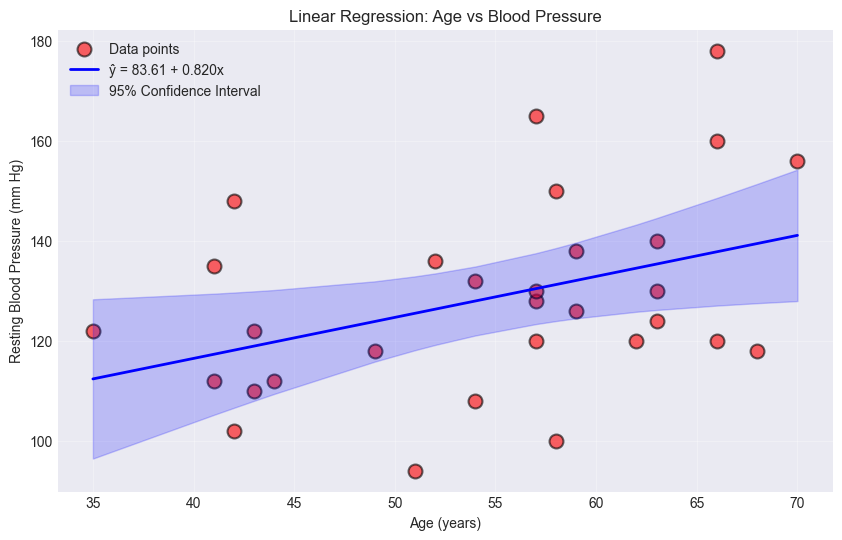


Regression equation: BP = 83.61 + 0.820 * Age

Interpretation: For each additional year of age, blood pressure
is predicted to increase by 0.820 mm Hg on average.


In [22]:
# Visualize the fitted model
beta_0 = model.params[0]
beta_1 = model.params[1]

plt.figure(figsize=(10, 6))
plt.scatter(
    age_reg,
    bp_reg,
    s=100,
    color="red",
    edgecolor="black",
    linewidth=1.5,
    label="Data points",
    alpha=0.6,
)

# Fitted line
x_line = np.linspace(age_reg.min(), age_reg.max(), 100)
y_line = beta_0 + beta_1 * x_line
plt.plot(x_line, y_line, "b-", linewidth=2, label=f"ŷ = {beta_0:.2f} + {beta_1:.3f}x")

# Add confidence interval
predictions = model.get_prediction(X_with_const)
prediction_summary = predictions.summary_frame(alpha=0.05)

# Sort for plotting
sort_idx = np.argsort(age_reg)
plt.fill_between(
    age_reg[sort_idx],
    prediction_summary.iloc[sort_idx]["mean_ci_lower"],
    prediction_summary.iloc[sort_idx]["mean_ci_upper"],
    alpha=0.2,
    color="blue",
    label="95% Confidence Interval",
)

plt.xlabel("Age (years)")
plt.ylabel("Resting Blood Pressure (mm Hg)")
plt.title("Linear Regression: Age vs Blood Pressure")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nRegression equation: BP = {beta_0:.2f} + {beta_1:.3f} * Age")
print(f"\nInterpretation: For each additional year of age, blood pressure")
print(
    f"is predicted to {'increase' if beta_1 > 0 else 'decrease'} by {abs(beta_1):.3f} mm Hg on average."
)

## Exercise 3.2: Residual Analysis

**Task:** Assess whether the regression assumptions are satisfied.

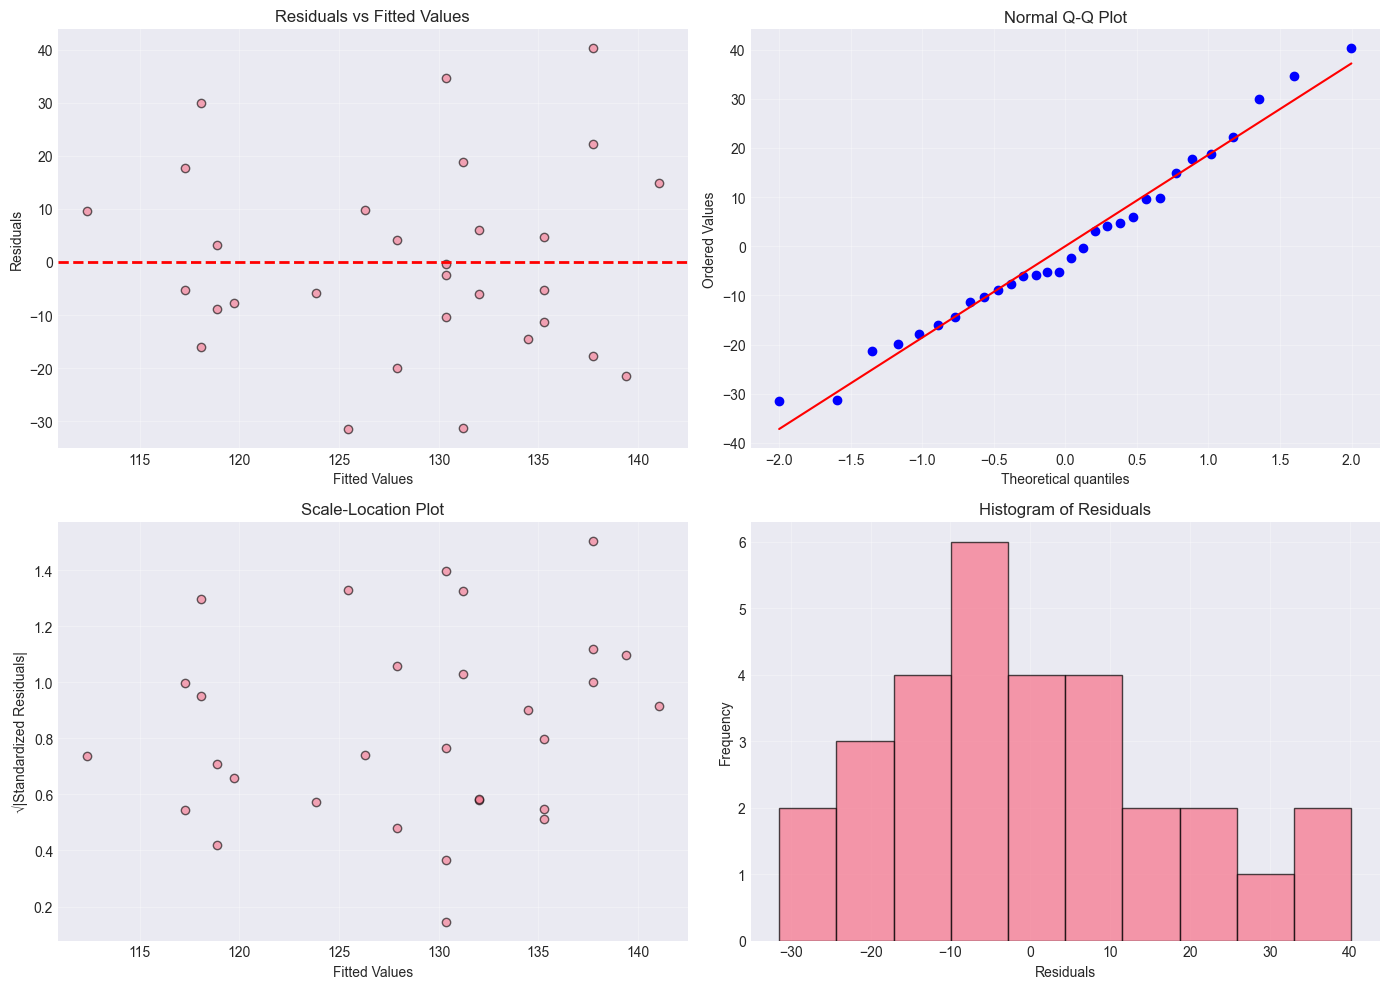

Residual Statistics:
Mean of residuals: 0.000000
Std dev of residuals: 17.775
Min residual: -31.458
Max residual: 40.235


In [23]:
# Residual diagnostics
residuals = model.resid
fitted_values = model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(fitted_values, residuals, alpha=0.6, edgecolor="black")
axes[0, 0].axhline(y=0, color="r", linestyle="--", linewidth=2)
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted Values")
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q plot
from scipy import stats as sp_stats

sp_stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q Plot")
axes[0, 1].grid(True, alpha=0.3)

# 3. Scale-Location
standardized_resid = residuals / np.std(residuals)
axes[1, 0].scatter(
    fitted_values, np.sqrt(np.abs(standardized_resid)), alpha=0.6, edgecolor="black"
)
axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel("√|Standardized Residuals|")
axes[1, 0].set_title("Scale-Location Plot")
axes[1, 0].grid(True, alpha=0.3)

# 4. Histogram of residuals
axes[1, 1].hist(residuals, bins=10, edgecolor="black", alpha=0.7)
axes[1, 1].set_xlabel("Residuals")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Histogram of Residuals")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Residual Statistics:")
print(f"Mean of residuals: {residuals.mean():.6f}")
print(f"Std dev of residuals: {residuals.std():.3f}")
print(f"Min residual: {residuals.min():.3f}")
print(f"Max residual: {residuals.max():.3f}")

**Questions to answer:**

1. **Linearity assumption:**
   - Look at the Residuals vs Fitted plot. What pattern indicates the linearity assumption is satisfied?
   - Do you see any systematic patterns (curves, trends)?

2. **Normality assumption:**
   - Examine the Q-Q plot. What should it look like if residuals are normally distributed?
   - Are there any points that deviate substantially from the line?
   - Look at the histogram. Does it appear approximately normal?

3. **Homoscedasticity (constant variance):**
   - In the Residuals vs Fitted plot, is the vertical spread of points roughly constant across fitted values?
   - What pattern in the Scale-Location plot would indicate heteroscedasticity?

4. **Independence:**
   - What assumption are we making about the independence of observations?
   - How might this assumption be violated in medical data?

5. Suppose the Residuals vs Fitted plot showed a clear funnel shape (wider on one end). What would this indicate? Which assumption is violated? What could you do about it?

6. If several points in the Q-Q plot fall far from the line at the tails, but most points follow it, would you be concerned? Why or why not?

7.  What is the difference between a residual and an error term? Can we ever observe the true error?

## Exercise 3.2: Hypothesis Test on Regression Coefficient

**Task:** Test if the slope is significantly different from zero (i.e., is there a significant relationship between age and blood pressure?).

**Hypotheses:**
- $H_0: \beta_1 = 0$ (no relationship)
- $H_1: \beta_1 \neq 0$ (significant relationship)

---
# Part 4: Logistic Regression

## Exercise 4.1: Simple Logistic Regression

**Context:** Predict the probability of heart disease based on age.

**Model:** 
$$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X)}}$$

Or in logit form:
$$\log\left(\frac{P(Y=1|X)}{1-P(Y=1|X)}\right) = \beta_0 + \beta_1 X$$

Sample data for logistic regression (n=20):

Age:            [34. 41. 41. 42. 50. 50. 54. 56. 56. 57. 57. 59. 60. 60. 60. 60. 61. 63.
 65. 65.]
Disease (0/1):  [0 0 0 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 0 0]

Fitted logistic regression (full data):
β₀ = -3.0507
β₁ = 0.0529

Logit equation: log(p/(1-p)) = -3.0507 + 0.0529×Age


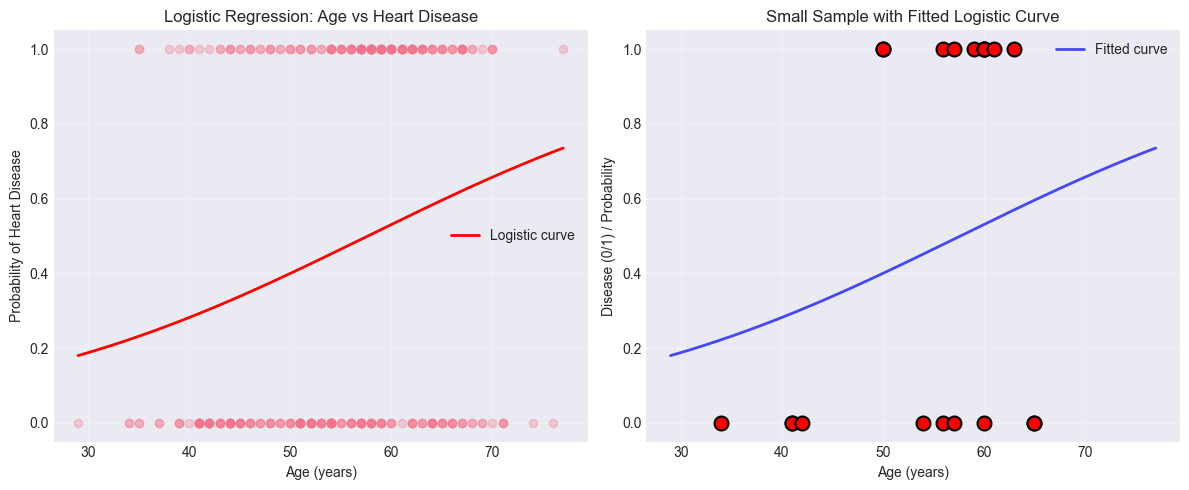

In [24]:
# Create a small sample for conceptual discussion
np.random.seed(777)
sample_indices_log = np.random.choice(len(df), size=20, replace=False)
age_log = df.iloc[sample_indices_log]["age"].values
disease_log = df.iloc[sample_indices_log]["target"].values

# Sort for better visualization
sort_idx = np.argsort(age_log)
age_log = age_log[sort_idx]
disease_log = disease_log[sort_idx]

print("Sample data for logistic regression (n=20):")
print("\nAge:           ", age_log)
print("Disease (0/1): ", disease_log)

# Fit logistic regression on full data for better illustration
from sklearn.linear_model import LogisticRegression

X_full = df[["age"]].values
y_full = df["target"].values

log_model = LogisticRegression()
log_model.fit(X_full, y_full)

beta_0_log = log_model.intercept_[0]
beta_1_log = log_model.coef_[0][0]

print(f"\nFitted logistic regression (full data):")
print(f"β₀ = {beta_0_log:.4f}")
print(f"β₁ = {beta_1_log:.4f}")
print(f"\nLogit equation: log(p/(1-p)) = {beta_0_log:.4f} + {beta_1_log:.4f}×Age")

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df["age"], df["target"], alpha=0.3)
age_range = np.linspace(df["age"].min(), df["age"].max(), 300)
prob_pred = 1 / (1 + np.exp(-(beta_0_log + beta_1_log * age_range)))
plt.plot(age_range, prob_pred, "r-", linewidth=2, label="Logistic curve")
plt.xlabel("Age (years)")
plt.ylabel("Probability of Heart Disease")
plt.title("Logistic Regression: Age vs Heart Disease")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(age_log, disease_log, s=100, color="red", edgecolor="black", linewidth=1.5)
plt.plot(age_range, prob_pred, "b-", linewidth=2, alpha=0.7, label="Fitted curve")
plt.xlabel("Age (years)")
plt.ylabel("Disease (0/1) / Probability")
plt.title("Small Sample with Fitted Logistic Curve")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Questions to answer:**

1. **Why logistic regression?**
   - What problems arise if we try to fit $Y = \beta_0 + \beta_1 X$ when $Y \in \{0,1\}$?
   - What constraints does the logistic function $ \sigma(z) = \frac{1}{1+e^{-z}}$ impose on predictions?

2. **Interpretation of coefficients:**
   - Given the fitted $\beta_1$, interpret this coefficient in words
   - Calculate the odds ratio: $e^{\beta_1}$
   - What does this tell us about the effect of age on disease risk?

3. **Making predictions:**
   - Calculate $P(\text{Disease}|\text{Age}=50)$ using the fitted model
   - Calculate $P(\text{Disease}|\text{Age}=60)$
   - How much does the probability change?

4. A logistic regression model yields: $\log(\frac{p}{1-p}) = -4.5 + 0.065 \times \text{Age}$

   - At what age does the model predict a 50% probability of heart disease?
   - Why doesn't logistic regression have a closed-form solution like OLS?

   - What is the probability of disease for a 45-year-old?
   - What assumptions does logistic regression make (versus linear regression)?

6.  

5. If $\beta_1 = 0.08$, by what factor do the odds of disease increase for a 10-year age increase?

## Exercise 4.2: Multiple Logistic Regression (Conceptual)

**Context:** Predict heart disease using multiple predictors: age, cholesterol, and sex.

**Model:**
$$\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 \cdot \text{Age} + \beta_2 \cdot \text{Chol} + \beta_3 \cdot \text{Sex}$$

In [25]:
# Fit multiple logistic regression
X_multiple = df[["age", "chol", "sex"]].values
y_multiple = df["target"].values

log_model_mult = LogisticRegression(max_iter=1000)
log_model_mult.fit(X_multiple, y_multiple)

print("Multiple Logistic Regression Results:")
print(f"\nβ₀ (intercept) = {log_model_mult.intercept_[0]:.4f}")
print(f"β₁ (age)       = {log_model_mult.coef_[0][0]:.4f}")
print(f"β₂ (chol)      = {log_model_mult.coef_[0][1]:.4f}")
print(f"β₃ (sex)       = {log_model_mult.coef_[0][2]:.4f}")

print(f"\nOdds ratios:")
print(
    f"Age:  e^{log_model_mult.coef_[0][0]:.4f} = {np.exp(log_model_mult.coef_[0][0]):.4f}"
)
print(
    f"Chol: e^{log_model_mult.coef_[0][1]:.4f} = {np.exp(log_model_mult.coef_[0][1]):.4f}"
)
print(
    f"Sex:  e^{log_model_mult.coef_[0][2]:.4f} = {np.exp(log_model_mult.coef_[0][2]):.4f}"
)

# Model performance
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = log_model_mult.predict(X_multiple)
accuracy = accuracy_score(y_multiple, y_pred)

print(f"\nModel accuracy: {accuracy:.3f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_multiple, y_pred))
print(f"\nClassification Report:")
print(classification_report(y_multiple, y_pred, target_names=["No Disease", "Disease"]))

Multiple Logistic Regression Results:

β₀ (intercept) = -5.6485
β₁ (age)       = 0.0618
β₂ (chol)      = 0.0043
β₃ (sex)       = 1.4895

Odds ratios:
Age:  e^0.0618 = 1.0638
Chol: e^0.0043 = 1.0043
Sex:  e^1.4895 = 4.4347

Model accuracy: 0.663

Confusion Matrix:
[[114  46]
 [ 54  83]]

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.68      0.71      0.70       160
     Disease       0.64      0.61      0.62       137

    accuracy                           0.66       297
   macro avg       0.66      0.66      0.66       297
weighted avg       0.66      0.66      0.66       297



**Questions to answer:**

1. **Interpretation:**
   - Interpret each coefficient in the context of the problem
   - Is the effect of sex positive or negative? What does this mean clinically?
   - Holding age and cholesterol constant, how do the odds of disease differ between males and females?

2. **Comparison:**
   - Compare the age coefficient in simple vs. multiple logistic regression
   - Why might they be different? What concept does this illustrate?

3. **Model evaluation:**
   - What does the confusion matrix tell us?
   - Calculate sensitivity and specificity from the confusion matrix
   - Is accuracy sufficient for evaluating this model? Why or why not?

4. If we add a fourth predictor and the coefficients change substantially, what might this indicate about the predictors?

5.  How are these coefficients estimated? Why use gradient descent/Newton's method rather than solving directly?

6. Suppose a patient has: Age=55, Cholesterol=220, Sex=1 (male). Calculate the probability of heart disease using the fitted coefficients.